# Importing necessary libraries and dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/sample_data/hotel_booking.csv")
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,Transient,96.14,0,0,Check-Out,2017-09-06,Claudia Johnson,Claudia.J@yahoo.com,403-092-5582,************8647
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,Transient,225.43,0,2,Check-Out,2017-09-07,Wesley Aguilar,WAguilar@xfinity.com,238-763-0612,************4333
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,Transient,157.71,0,4,Check-Out,2017-09-07,Mary Morales,Mary_Morales@hotmail.com,395-518-4100,************1821
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,Transient,104.40,0,0,Check-Out,2017-09-07,Caroline Conley MD,MD_Caroline@comcast.net,531-528-1017,************7860


# Understanding the dataset

In [ ]:
df.shape

(119390, 36)

In [ ]:
display(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

None

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


# Basic Counting/Proportions related graphs

In [ ]:
df['hotel'].value_counts()

,count
hotel,
City Hotel,79330
Resort Hotel,40060


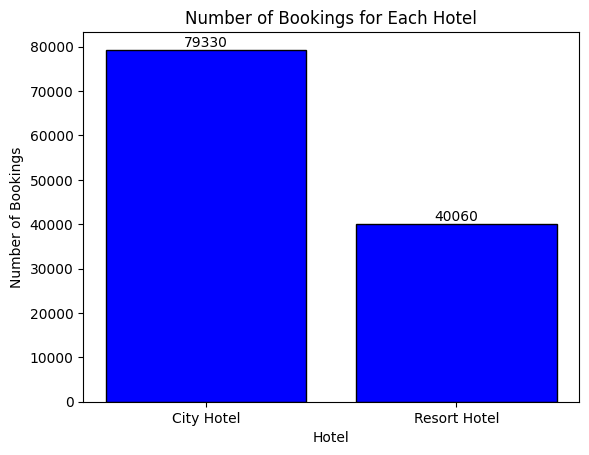

In [ ]:
hotel_wise_bookings = df['hotel'].value_counts()
x = hotel_wise_bookings.index
y = hotel_wise_bookings.values
plt.bar(x, y, color='blue', edgecolor='black')
plt.xlabel('Hotel')
plt.ylabel('Number of Bookings')
plt.title('Number of Bookings for Each Hotel')
plt.bar_label(plt.gca().containers[0])
plt.show()

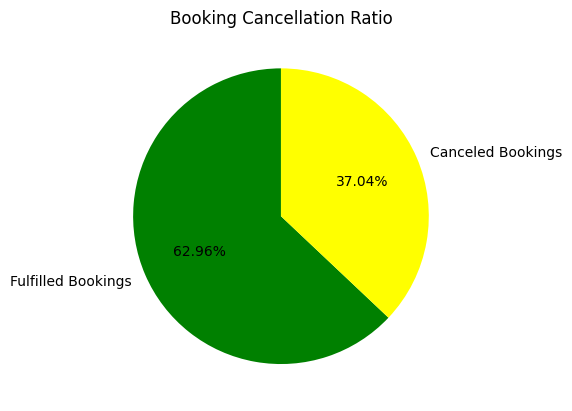

In [ ]:
cancel = df['is_canceled'].value_counts()
cancel.index = cancel.index.map({0: 'Fulfilled Bookings', 1: 'Canceled Bookings'})
x = cancel.index
y = cancel.values
plt.pie(y, labels=x, autopct='%1.2f%%', startangle=90, colors=['green', 'yellow'])
plt.title('Booking Cancellation Ratio')
plt.show()

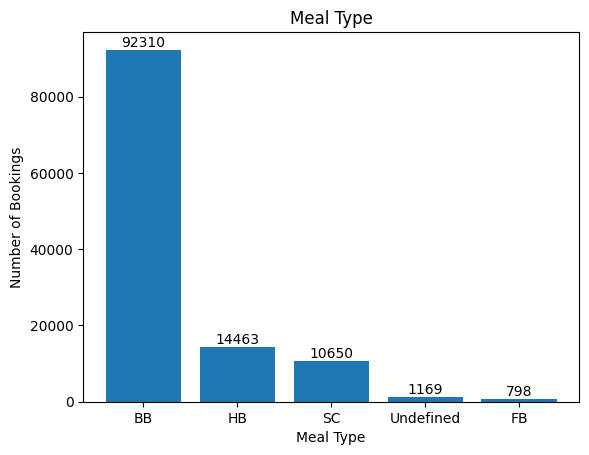

In [ ]:
meal_type = df['meal'].value_counts()
x = meal_type.index
y = meal_type.values
plt.bar(x, y)
plt.title('Meal Type')
plt.xlabel('Meal Type')
plt.ylabel('Number of Bookings')
plt.bar_label(plt.gca().containers[0])
plt.show()

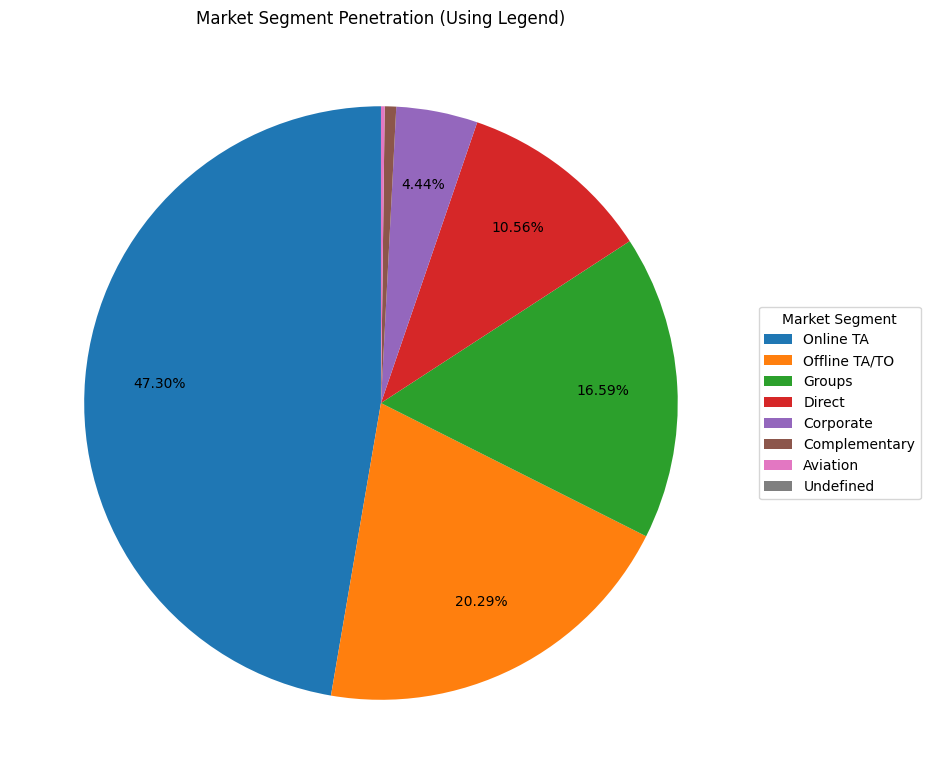

In [ ]:
market = df['market_segment'].value_counts()
x = market.index
y = market.values

plt.figure(figsize=(9, 8))
plt.pie(
    y,
    autopct=lambda pct: f'{pct:1.2f}%' if pct > 2 else '',
    startangle=90,
    pctdistance=0.75,
)

plt.legend(x, title='Market Segment', loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Market Segment Penetration (Using Legend)')
plt.tight_layout()
plt.show()

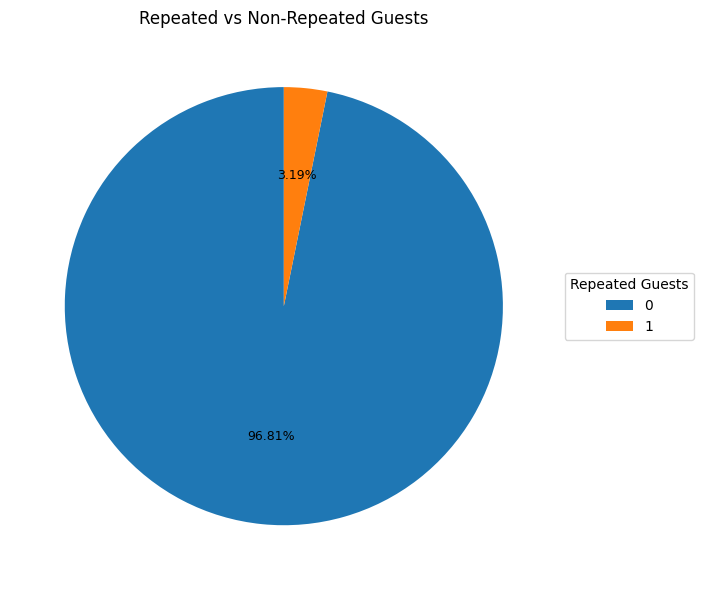

In [ ]:
repeated_guests = df['is_repeated_guest'].value_counts()
x = repeated_guests.index
y = repeated_guests.values

plt.figure(figsize=(7, 6))
plt.pie(
    y,
    autopct=lambda pct: f'{pct:1.2f}%',
    startangle=90,
    textprops={'fontsize': 9}
)

plt.legend(x, title='Repeated Guests', loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Repeated vs Non-Repeated Guests')
plt.tight_layout()
plt.show()

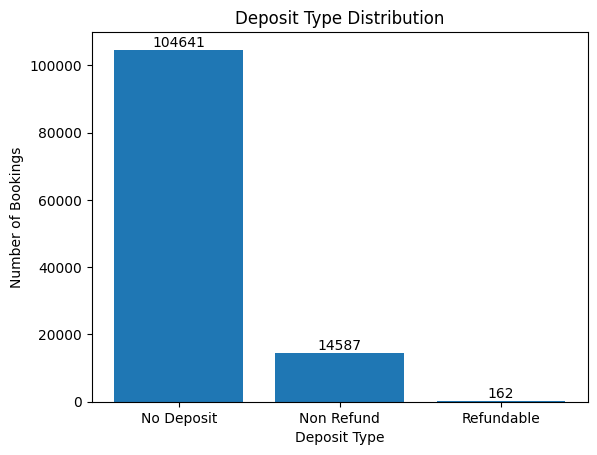

In [ ]:
deposit_type = df['deposit_type'].value_counts()

x = deposit_type.index
y = deposit_type.values

plt.bar(x, y)
plt.title('Deposit Type Distribution')
plt.xlabel('Deposit Type')
plt.ylabel('Number of Bookings')
plt.bar_label(plt.gca().containers[0])
plt.show()


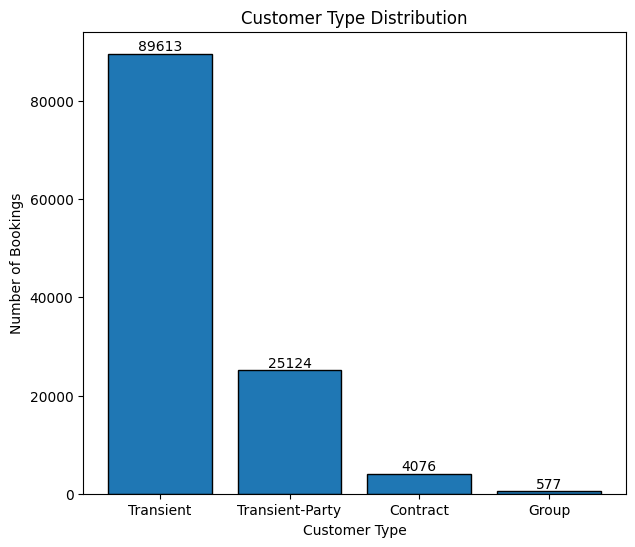

In [ ]:
customer_type = df['customer_type'].value_counts()

x = customer_type.index
y = customer_type.values

plt.figure(figsize=(7, 6))
plt.bar(x, y, edgecolor = 'black')
plt.title('Customer Type Distribution')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')
plt.bar_label(plt.gca().containers[0])
plt.show()

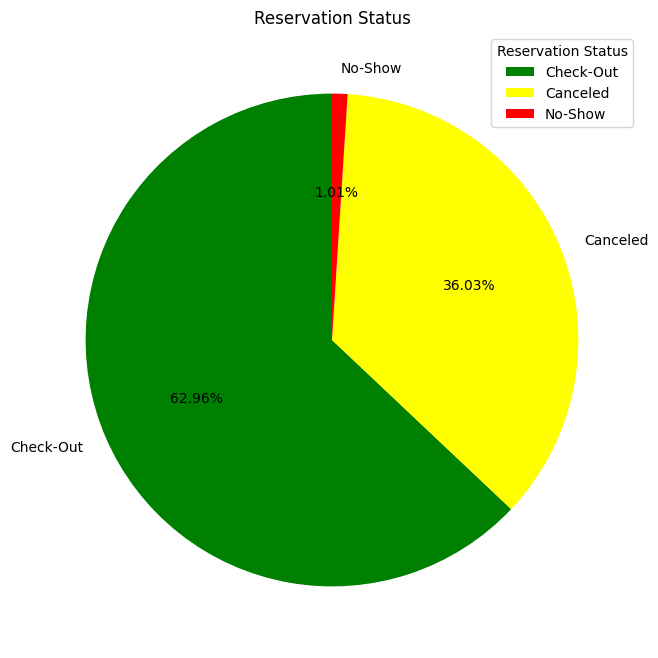

In [ ]:
reservation_stat = df['reservation_status'].value_counts()

x = reservation_stat.index
y = reservation_stat.values

plt.figure(figsize=(9, 8))
plt.pie(y, labels=x, autopct='%1.2f%%', startangle=90, colors=['green', 'yellow', 'red'])
plt.legend(title='Reservation Status')
plt.title('Reservation Status')
plt.show()

In [ ]:
#df['distribution_channel'].value_counts()
#cancelled for now, not needed now

/tmp/ipykernel_492/2075416505.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna(df['country'].mode()[0], inplace=True)


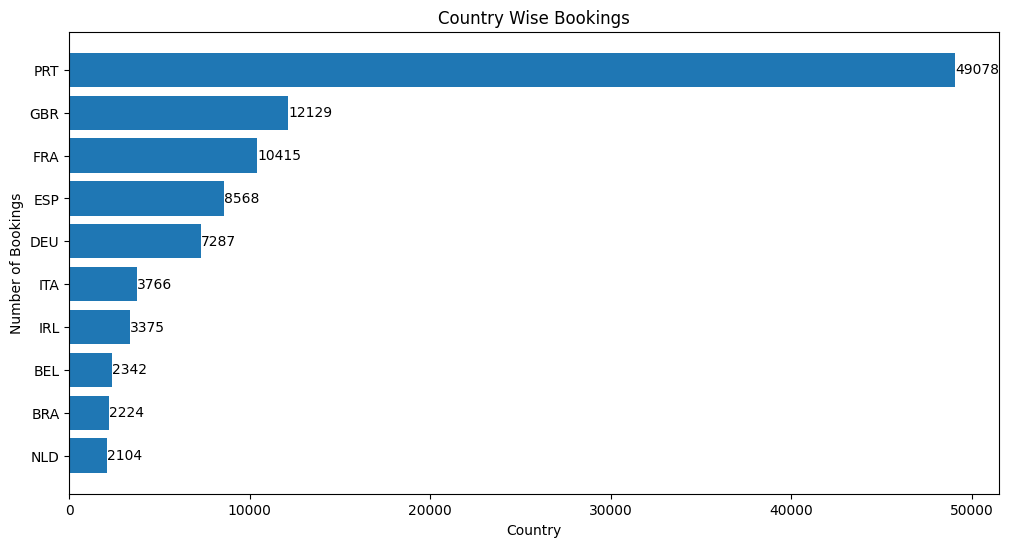

In [ ]:
df['country'].fillna(df['country'].mode()[0], inplace=True)
country_wise_bookings = df['country'].value_counts().head(10).sort_values(ascending=True)
x = country_wise_bookings.index
y = country_wise_bookings.values
plt.figure(figsize=(12, 6))
plt.barh(x, y)
plt.title('Country Wise Bookings')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')
plt.bar_label(plt.gca().containers[0])
plt.show()

# Room types and comparision

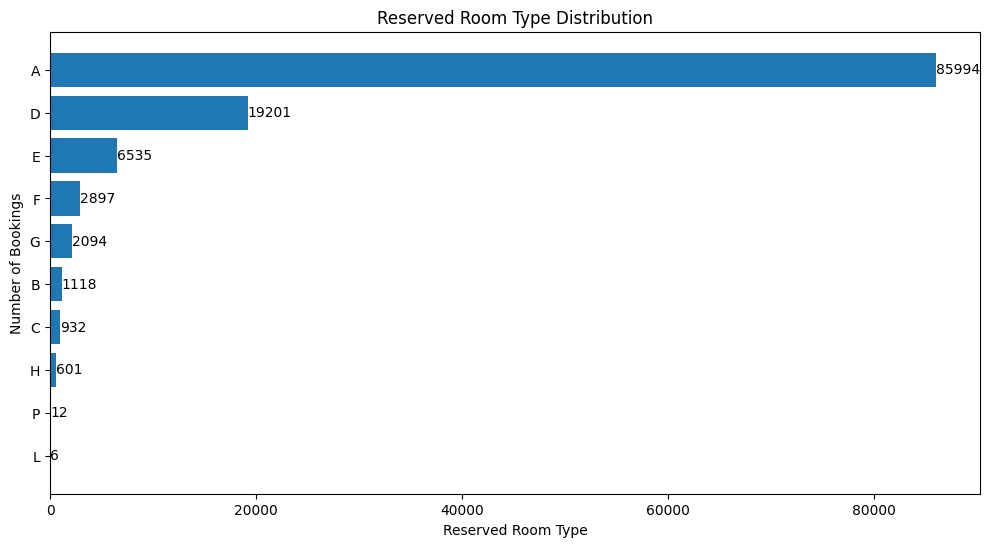

In [ ]:
reserved_room = df['reserved_room_type'].value_counts().sort_values(ascending=True)
#assigned_room = df['assigned_room_type'].value_counts().sorted(ascending=False)

x = reserved_room.index
y = reserved_room.values

plt.figure(figsize=(12, 6))
plt.barh(x, y)
plt.title('Reserved Room Type Distribution')
plt.xlabel('Reserved Room Type')
plt.ylabel('Number of Bookings')
plt.bar_label(plt.gca().containers[0])
plt.show()

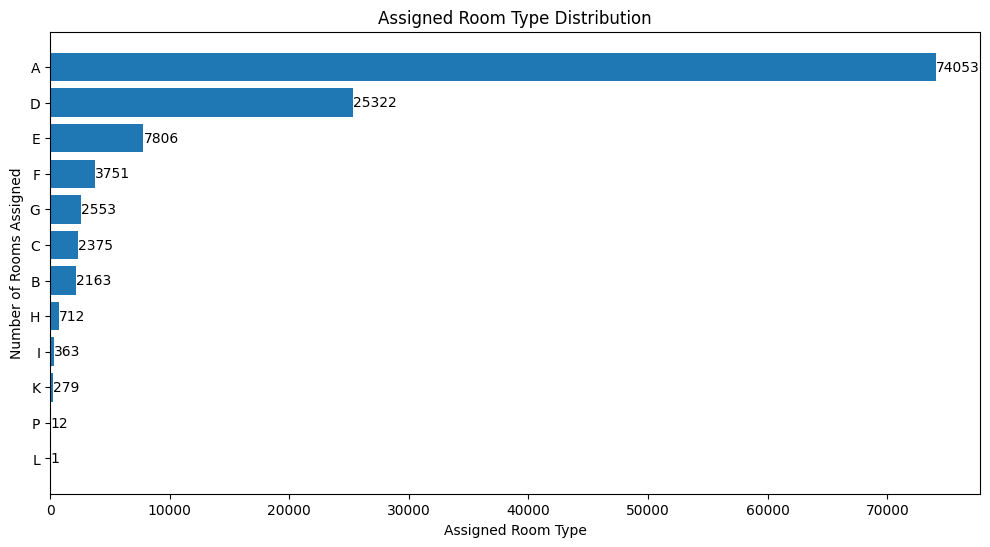

In [ ]:

assigned_room = df['assigned_room_type'].value_counts().sort_values(ascending=True)

x = assigned_room.index
y = assigned_room.values

plt.figure(figsize=(12, 6))
plt.barh(x, y)
plt.title('Assigned Room Type Distribution')
plt.xlabel('Assigned Room Type')
plt.ylabel('Number of Rooms Assigned')
plt.bar_label(plt.gca().containers[0])
plt.show()

NameError: name 'ax' is not defined

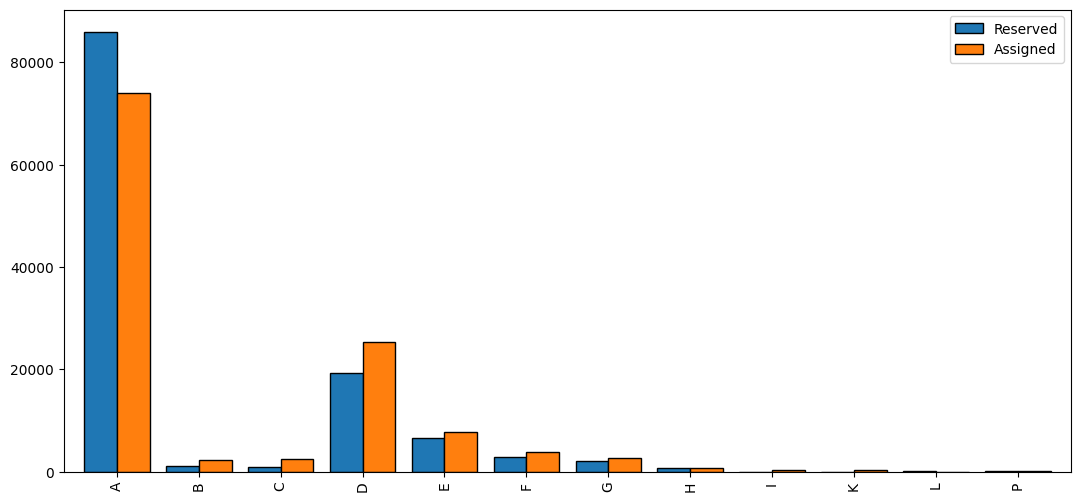

In [ ]:
assigned_room = df['assigned_room_type'].value_counts()
reserved_room = df['reserved_room_type'].value_counts()


df_chart = pd.DataFrame(
    {
        "Reserved": df["reserved_room_type"].value_counts(),
        "Assigned": df["assigned_room_type"].value_counts(),
    }
).fillna(0)

df_chart.plot(kind="bar", width=0.8, figsize=(13, 6), edgecolor="black")

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

plt.title("Room Type: Reserved vs Assigned", fontsize=14)
plt.xlabel("Room Type", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.bar_label(plt.gca().containers[0], fontsize=9)
plt.bar_label(plt.gca().containers[1], fontsize=9)
plt.ylim(0, df_chart.max().max() * 1.1)

plt.tight_layout()
plt.show()

In [ ]:
#change in the room assigned w.r.t. room reserved

#room_change = df[df['reserved_room_type'] != df['assigned_room_type']].shape[0]
# room_unchanged = df[df['reserved_room_type'] == df['assigned_room_type']].shape[0]

df['room_change'] = df['reserved_room_type'] != df['assigned_room_type']

# Overall counts
room_change_counts = df['room_change'].value_counts()
room_change_pct = df['room_change'].value_counts(normalize=True) * 100

print(room_change_counts)
print(room_change_pct.round(2))

plt.figure(figsize=(7, 7))
labels = ['Same Room', 'Changed Room']
sizes = [room_change_counts[False], room_change_counts[True]]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0)

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=90,
        textprops={'fontsize': 12})

plt.title('Room Type Assignment\n(Same Room vs Changed Room)', fontsize=14, pad=20)
plt.axis('equal')
plt.legend(title='Room Assignment', loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [ ]:
summary = df.groupby(['hotel', 'room_change']).size().unstack(fill_value=0)
summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100

# Plot
plt.figure(figsize=(9, 6))
summary_pct.plot(kind='bar', color=['#66b3ff', '#ff9999'], width=0.7)

plt.title('Room Type Change Rate by Hotel', fontsize=14, pad=15)
plt.xlabel('Hotel', fontsize=12)
plt.ylabel('Percentage of Bookings (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Same Room', 'Changed Room'], title='Room Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
bdf.groupby(['hotel', 'room_change']).size().unstack(fill_value=0)

# People and Stay Duration

In [ ]:
# sns.set_theme(style='darkgrid', palette="muted")
city_hotel_data = df[df['hotel'] == 'City Hotel']['lead_time']
resort_hotel_data = df[df['hotel'] == 'Resort Hotel']['lead_time']

plot_data = [city_hotel_data, resort_hotel_data]
labels = ['City Hotel', 'Resort Hotel']
colors = ['blue', 'green']

plt.figure(figsize=(7, 5))
plt.xlabel('Hotel Type')
plt.ylabel('Lead Time')
plt.xticks(ticks=[1, 2], labels=labels)
plt.title('Lead Time Distribution by Hotel Type')
plt.boxplot(plot_data, tick_labels=['City Hotel', 'Resort Hotel'])
plt.show()

plt.figure(figsize=(7, 5))
plt.violinplot(plot_data, showmeans=True)
plt.xticks(ticks=[1, 2], labels=labels)
plt.xlabel('Hotel Type')
plt.ylabel('Lead Time')
plt.title('Lead Time Distribution by Hotel Type')
plt.grid(True)
plt.show()

### Merge arrival date columns into one column

In [ ]:
year = df['arrival_date_year'].astype(str)
month = df['arrival_date_month'].astype(str)
day = df['arrival_date_day_of_month'].astype(str)

# Make a new revised column
temp_dates = pd.to_datetime(year + '-' + month + '-' + day, format='%Y-%B-%d')
df['arrival_date'] = temp_dates.dt.strftime('%Y-%m-%d')

# Drop the rest of the columns
df = df.drop(['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month'], axis=1)


In [ ]:
df['arrival_year_month'] = df['arrival_date'].str[:7]

monthly_arrivals = df['arrival_year_month'].value_counts().sort_index()
x = monthly_arrivals.index
y = monthly_arrivals.values

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linestyle='-', color='green')
plt.xlabel('Month')
plt.ylabel('Number of Arrivals')
plt.title('Monthly Arrivals')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
total_days = (df['stays_in_weekend_nights'] + df['stays_in_week_nights']).value_counts().sort_index()
x = total_days.index
y = total_days.values
plt.bar(x, y)
plt.title('Total Days of Stay')
plt.xlabel('Total Days')
plt.ylabel('Number of Bookings')
plt.show()

In [ ]:
df['total_people'] = df['adults'] + df['children'] + df['babies']
total_people = df['total_people'].value_counts().sort_index()
x = total_people.index
y = total_people.values
plt.bar(x, y)
plt.title('Total People in Bookings')
plt.xlabel('Total People')
plt.ylabel('Number of Bookings')
plt.show()

In [ ]:
total_people

In [ ]:
df['market_segment'].value_counts()

In [ ]:
df['reserved_room_type'].value_counts()

In [ ]:
df.columns

1. Hotel vs number_of_people : bar chart - done
2. number of people - is_cancelled vs is_not_cancelled : pie_chart
    (represent precentages) - done
3. leadtime vs hotel_name : box/violin plot - done
4. merge arrival_date_year, arrival_date_month, arrival_date_day_of_month --> arrival_date - done

5. no_of_people vs stay_in_weekend_nights/stay_in_week_nights : bar/pie plot --**done partially

6. adults + babies + childern --> total_people (generate new col) --**done partially

7. count vs meal : bar chart - done
8. country : bar chart - done
9. market_segment : pie chart - done
10. is_repeated_guest : pie - done
11. reserved_room_type: bar/pie
12. assigned_room_type and reserved_room_type : side by side bar chart
13. deposit_type w.r.t each hotel : side by side bar plot (for each hotel three deposit_types)three
14. chanchange the type of agent id from float to int/strge the type of agent id from float to int/str
15. change the type of company from float to int/str
16. days_in_waiting_list : one histogram per hotel
17. customer_type vs assigned_room_type : bar chart
18. adr vs assigned_room_type : bar chart
19. required_car_parking_spaces vs customer_type : bar
20. total_of_special_requests vs adr : heatmap
21. reservation_status : bar (depends on what can once be thought)